In [1]:
import os
import cantera as ct
import numpy as np
import pandas as pd
import ess
import glob
# import sys
# sys.path.append(os.path.join(os.environ['UNCERTAINTY_REPO'], 'bpe', 'simulation'))  # Cantera simulation
# import simulation
import yaml
import logging

# import importlib
# importlib.reload(simulation)

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
logging.basicConfig()
logging.getLogger().setLevel(logging.INFO)


In [3]:
working_dir = '/scratch/harris.se/guassian_scratch/mk3_runs/multi_20260210/'
correlated = True
if correlated:
    label = 'corr'
else:
    label = 'uncorr'
example_run_dir = os.path.join(working_dir, f'cpox_{label}', f'cpox_{label}_0000')

In [4]:
sim_info_yaml = os.path.join(example_run_dir, 'sim_info.yaml')
with open(sim_info_yaml) as f:
    sim_info = yaml.safe_load(f)

In [5]:
chain_0s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'chain_0.npy')))
chain_1s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'chain_1.npy')))

logp_0s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'logPs_0.npy')))
logp_1s = sorted(glob.glob(os.path.join(working_dir, f'cpox_{label}', '*', 'results', 'logPs_1.npy')))

# Keep a running tally of the top n

In [6]:
n = 100
N_params = len(sim_info['parameter_names'])
def add_new_data_point(array_of_top_n_logPs, array_of_top_n_MAPs, new_logPs, new_MAPs):
    array_of_logPs = np.concatenate((array_of_top_n_logPs, new_logPs))
    array_of_MAPs = np.concatenate((array_of_top_n_MAPs, new_MAPs))
    array_of_top_n_MAPs = np.zeros((n, N_params))
    array_of_top_n_logPs = np.zeros(n)

    indices = np.arange(array_of_logPs.shape[0])
    sorted_order = [x for _, x in sorted(zip(array_of_logPs, indices))][::-1]
    
    for i in range(n):
        array_of_top_n_MAPs[i, :] = array_of_MAPs[sorted_order[i], :]
        array_of_top_n_logPs[i] = array_of_logPs[sorted_order[i]]

    return array_of_top_n_logPs, array_of_top_n_MAPs

    

In [7]:
all_run_MAPs = []
all_run_logPs = []

for j in range(len(chain_0s)):
    
    chain0 = np.load(chain_0s[j])
    logP0 = np.load(logp_0s[j])
    chain1 = np.load(chain_0s[j])
    logP1 = np.load(logp_0s[j])


    list_of_top_n_logPs = []
    list_of_top_n_MAPs = []
    
    top_n_logPs = np.ones(n) * -np.inf
    top_n_MAPs = np.zeros((n, N_params)) + np.nan
    
    for i in range(logP0.shape[0]):
        new_logPs = logP0[i, :]
        new_MAPs = chain0[i, :, :]
        top_n_logPs, top_n_MAPs = add_new_data_point(top_n_logPs, top_n_MAPs, new_logPs, new_MAPs)
    
        new_logPs = logP1[i, :]
        new_MAPs = chain1[i, :, :]
        top_n_logPs, top_n_MAPs = add_new_data_point(top_n_logPs, top_n_MAPs, new_logPs, new_MAPs)
        
        list_of_top_n_logPs.append(top_n_logPs)
        list_of_top_n_MAPs.append(top_n_MAPs)

    all_run_MAPs.append(list_of_top_n_MAPs)
    all_run_logPs.append(list_of_top_n_logPs)

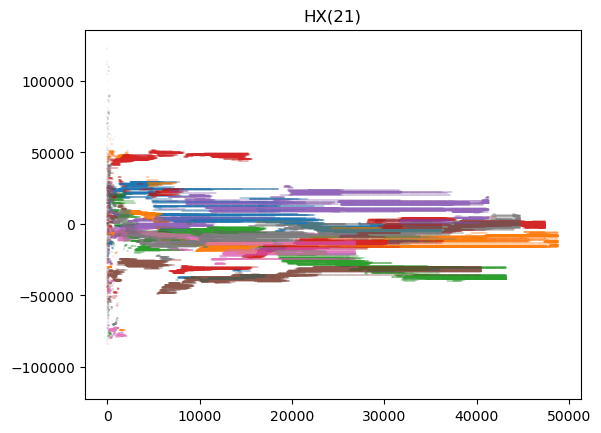

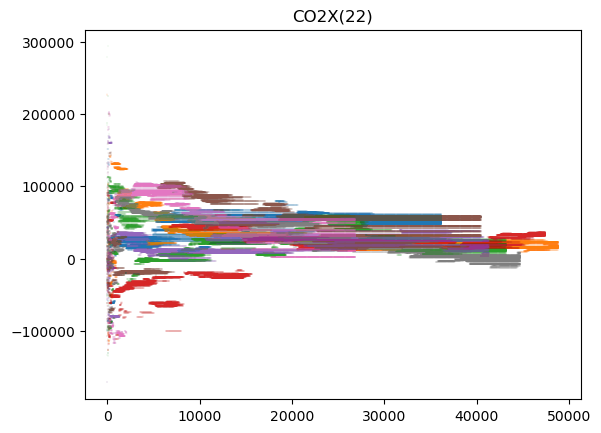

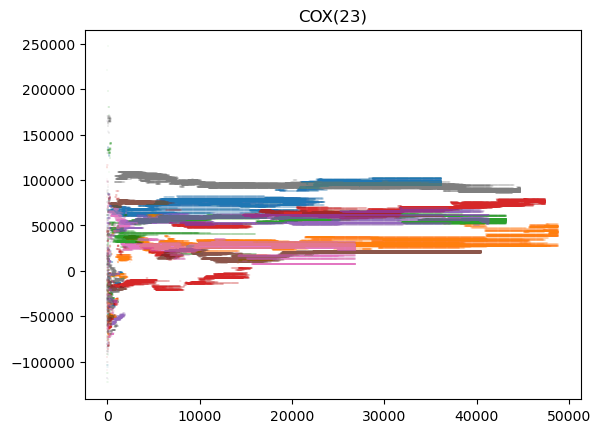

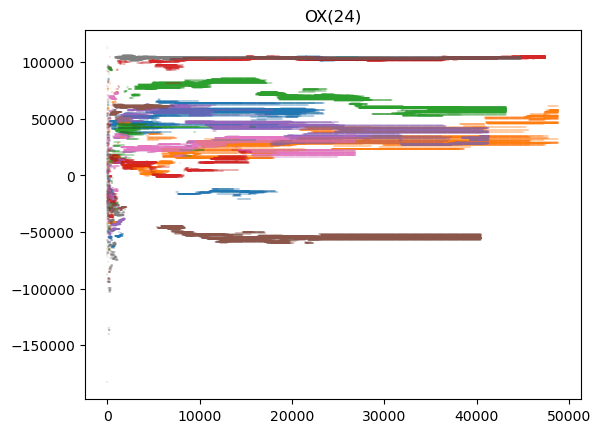

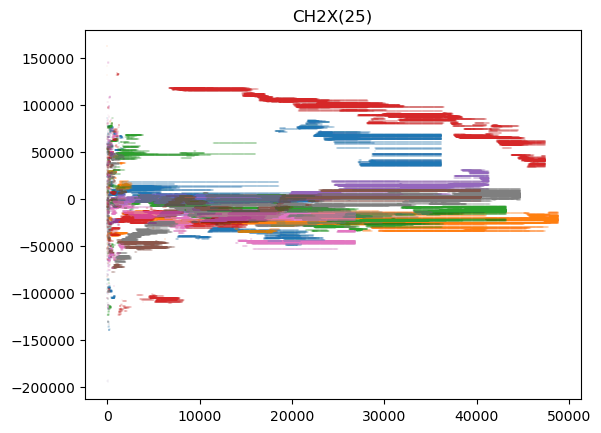

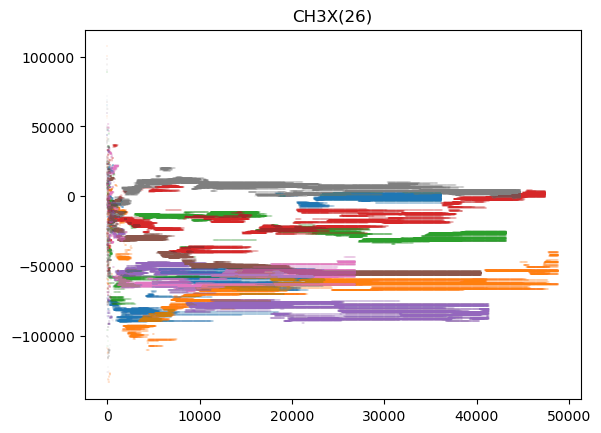

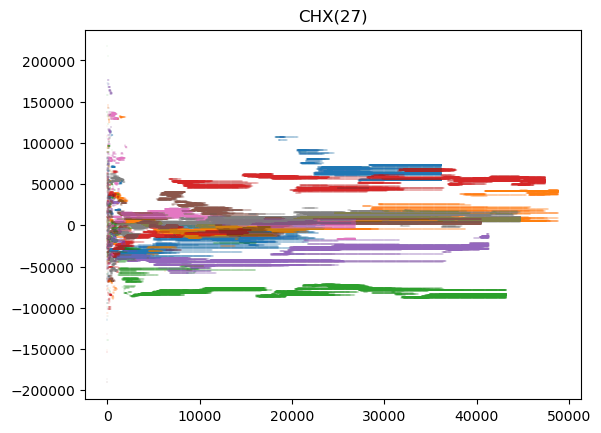

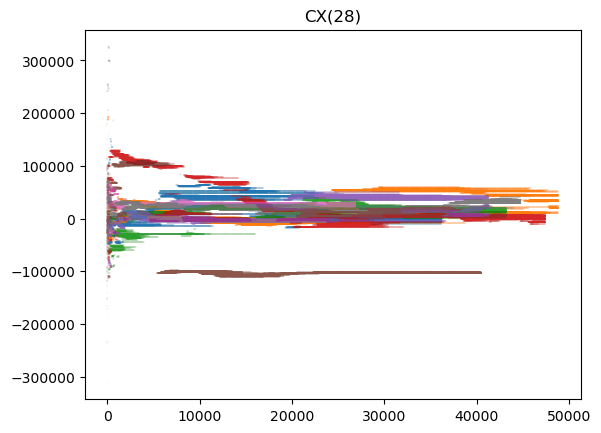

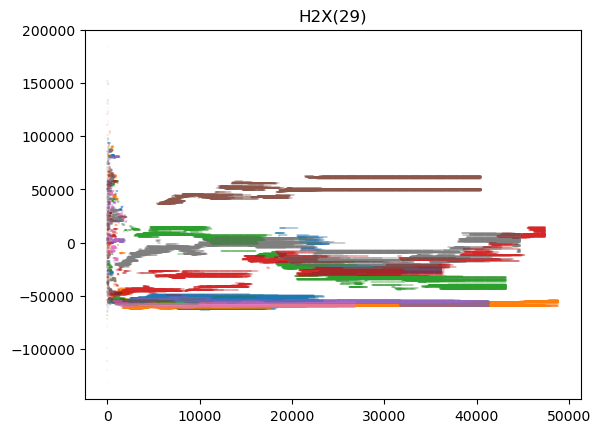

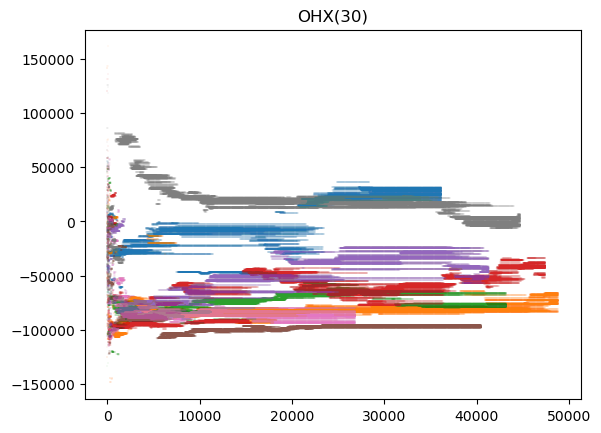

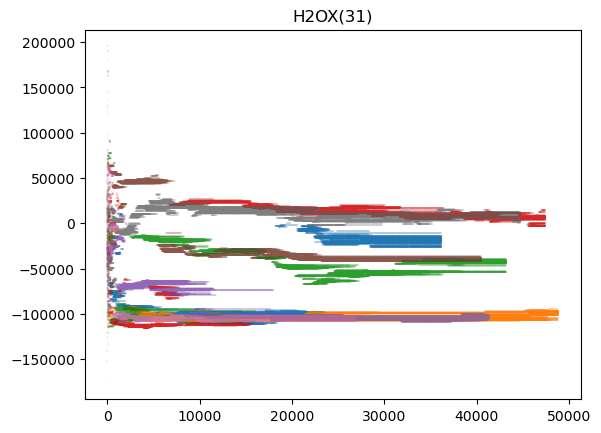

In [8]:
for i in range(N_params):
    for j in range(len(chain_0s)):
        list_of_top_n_MAPs = all_run_MAPs[j]
        MAPS = np.array(list_of_top_n_MAPs)[:, :, i]
        sample_indices = np.tile(np.arange(MAPS.shape[0]) * chain0.shape[1], (n, 1)).T
        plt.scatter(sample_indices, MAPS, alpha=0.02, s=2, marker='_', label=f'run_{j}')
    # plt.legend()
    plt.title(sim_info['parameter_names'][i])
    plt.show()

# Plot enthalpy of reaction instead of absolute enthalpy

## First, find relevant reactions that have the species of interest

In [9]:
example_mech_yaml = os.path.join(example_run_dir, 'chem_annotated.yaml')
gas = ct.Solution(example_mech_yaml)
surf = ct.Interface(example_mech_yaml, "surface1", [gas])

In [10]:
reactions_of_interest = []
for i in range(surf.n_reactions):
    relevant_species = 0
    for key in surf.reactions()[i].reactants:
        if key in sim_info['parameter_names']:
            relevant_species += 1
    for key in surf.reactions()[i].products:
        if key in sim_info['parameter_names']:
            relevant_species += 1
    if relevant_species > 1:
        reactions_of_interest.append(i)
# for i in range(len(reactions_of_interest)):
#     print(reactions_of_interest[i], surf.reactions()[reactions_of_interest[i]].equation)

In [11]:
surf.reactions()[4]

COX(23) + OX(24) <=> CO2X(22) + X(1)    <interface-Blowers-Masel>

In [12]:
list_of_top_n_MAPs[100].shape

(100, 11)

In [13]:
def get_reaction_enthalpy(gas, surf, reaction_index, parameter_adjustments_J_mol=None, T=1000):
    """function to compute the reaction enthalpy when the parameters are perturbed as described in parameter set"""
    # get the base enthalpy of reaction (at 1000 K?)
    enthalpy_of_reaction = 0
    if parameter_adjustments_J_mol is None:
        parameter_adjustments_J_mol = []
    
    rxn = surf.reactions()[reaction_index]
    for key in rxn.products:
        if key in surf.species_names:
            j = surf.species_names.index(key)
            h_sp = surf.species()[j].thermo.h(T) / 1000.0  # convert from J/kmol to J/mol
            enthalpy_of_reaction += h_sp * rxn.products[key]
        elif key in gas.species_names:
            j = gas.species_names.index(key)
            h_sp = gas.species()[j].thermo.h(T) / 1000.0  # convert from J/kmol to J/mol
            enthalpy_of_reaction += h_sp * rxn.products[key]
        else:
            raise KeyError

        if key in sim_info['parameter_names']:
            stoich = rxn.products[key]
            
            k = sim_info['parameter_names'].index(key)
            adjustment = parameter_adjustments_J_mol[k] * stoich
            enthalpy_of_reaction += adjustment
            

    for key in rxn.reactants:
        if key in surf.species_names:
            j = surf.species_names.index(key)
            h_sp = surf.species()[j].thermo.h(T) / 1000.0
            enthalpy_of_reaction -= h_sp * rxn.reactants[key]
        elif key in gas.species_names:
            j = gas.species_names.index(key)
            h_sp = gas.species()[j].thermo.h(T) / 1000.0  # convert from J/kmol to J/mol
            enthalpy_of_reaction += h_sp * rxn.reactants[key]
        else:
            raise KeyError


        if key in sim_info['parameter_names']:
            stoich = rxn.reactants[key]
            
            k = sim_info['parameter_names'].index(key)
            adjustment = parameter_adjustments_J_mol[k] * stoich
            enthalpy_of_reaction -= adjustment
    return enthalpy_of_reaction
        
        

    

In [14]:
def get_enthalpy_of_reaction(gas, surf, reaction_index, T=1000):
    """function to compute the reaction enthalpy when the parameters are perturbed as described in parameter set"""
    # get the base enthalpy of reaction (at 1000 K?)
    enthalpy_of_reaction = 0
    
    rxn = surf.reactions()[reaction_index]
    for key in rxn.products:
        if key in surf.species_names:
            j = surf.species_names.index(key)
            h_sp = surf.species()[j].thermo.h(T) / 1000.0  # convert from J/kmol to J/mol
            enthalpy_of_reaction += h_sp * rxn.products[key]
        elif key in gas.species_names:
            j = gas.species_names.index(key)
            h_sp = gas.species()[j].thermo.h(T) / 1000.0  # convert from J/kmol to J/mol
            enthalpy_of_reaction += h_sp * rxn.products[key]
        else:
            raise KeyError

    for key in rxn.reactants:
        if key in surf.species_names:
            j = surf.species_names.index(key)
            h_sp = surf.species()[j].thermo.h(T) / 1000.0
            enthalpy_of_reaction -= h_sp * rxn.reactants[key]
        elif key in gas.species_names:
            j = gas.species_names.index(key)
            h_sp = gas.species()[j].thermo.h(T) / 1000.0  # convert from J/kmol to J/mol
            enthalpy_of_reaction += h_sp * rxn.reactants[key]
        else:
            raise KeyError

    return enthalpy_of_reaction


In [83]:
# def get_adjustment_to_H_rxn(gas, surf, reaction_index, parameter_adjustments_J_mol, T=1000):
#     """compute adjustments to base H_rxn when the parameters are perturbed by parameter_adjustments_J_mol"""
#     enthalpy_of_adjustment = 0
    
#     for i in range(len(parameter_adjustments_J_mol)):
#         surf_species_index = sim_info['prior_species_indices'][i]
#         # they list surface species first, then gas
#         stoich = surf.product_stoich_coeffs[surf_species_index, reaction_index] - surf.reactant_stoich_coeffs[surf_species_index, reaction_index]
#         adjustment = parameter_adjustments_J_mol[i] * stoich
#         enthalpy_of_adjustment += adjustment

#     return enthalpy_of_adjustment

def get_adjustment_to_H_rxn(gas, surf, reaction_index, parameter_adjustments_J_mol, T=1000):
    """compute adjustments to base H_rxn when the parameters are perturbed by parameter_adjustments_J_mol"""
    enthalpy_of_adjustment = 0
    stoich_matrix = np.zeros_like(parameter_adjustments_J_mol)
    for i in range(len(parameter_adjustments_J_mol)):
        surf_species_index = sim_info['prior_species_indices'][i]
        # they list surface species first, then gas
        stoich_matrix[i] = surf.product_stoich_coeffs[surf_species_index, reaction_index] - surf.reactant_stoich_coeffs[surf_species_index, reaction_index]
    enthalpy_of_adjustment = np.dot(parameter_adjustments_J_mol, stoich_matrix)
    return enthalpy_of_adjustment

    

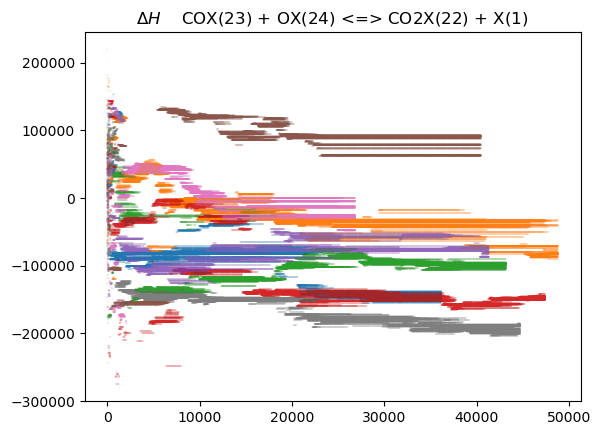

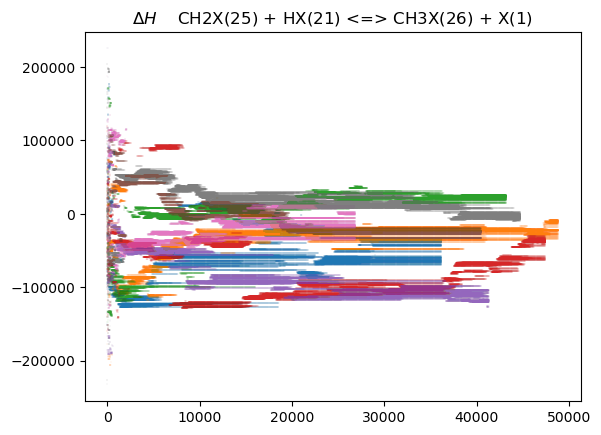

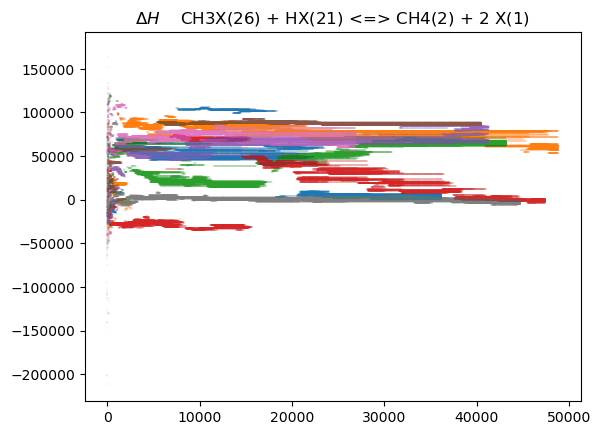

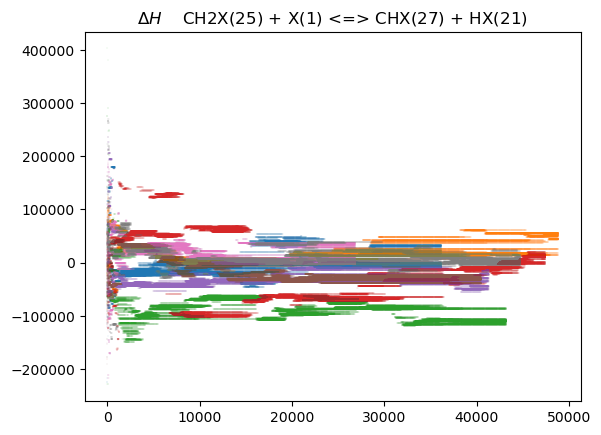

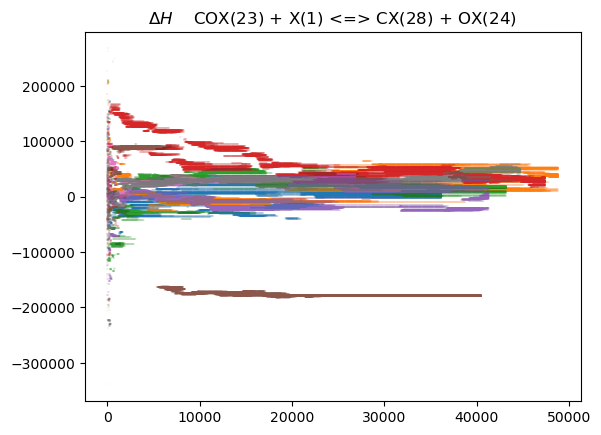

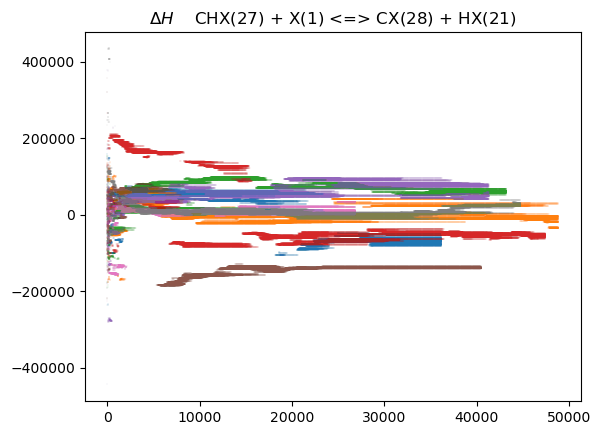

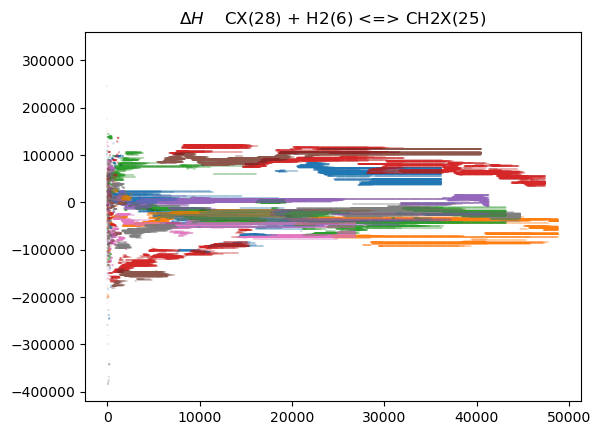

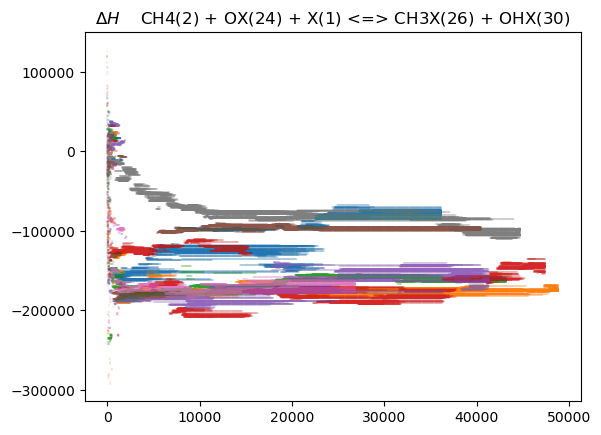

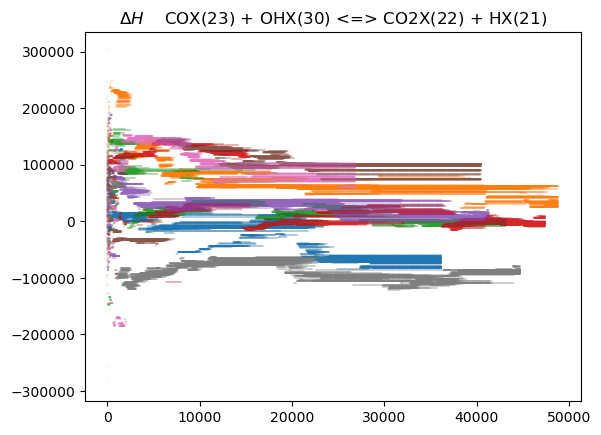

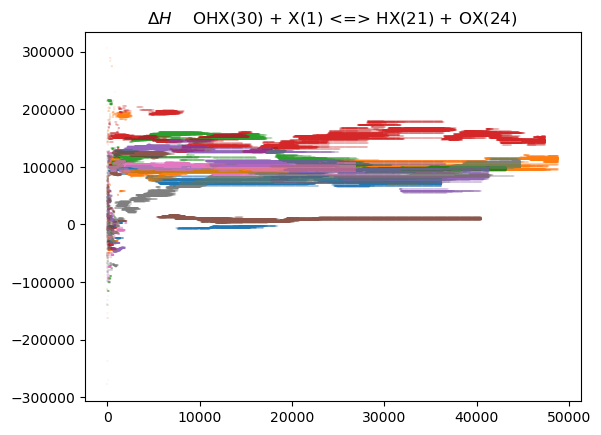

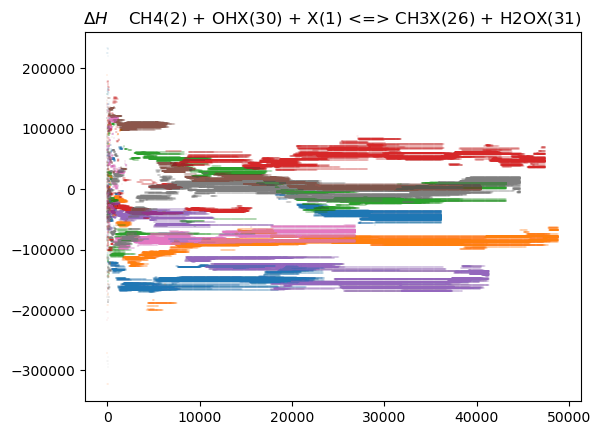

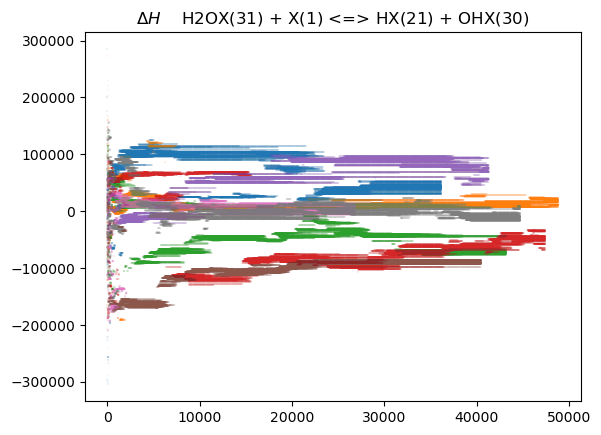

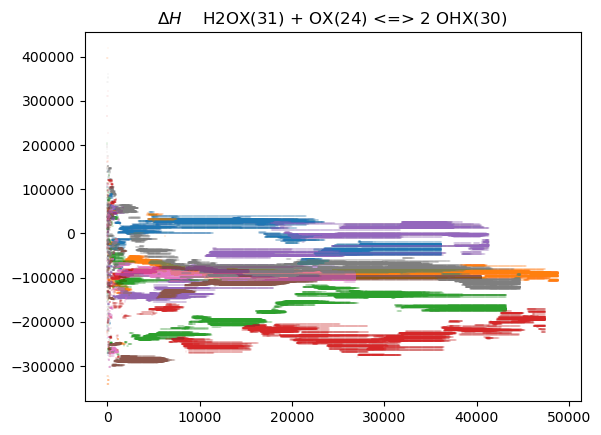

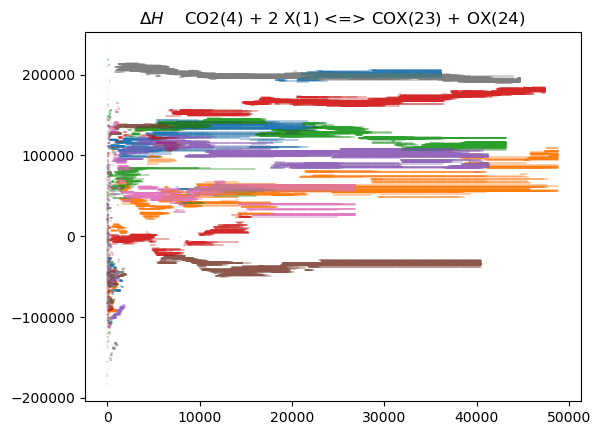

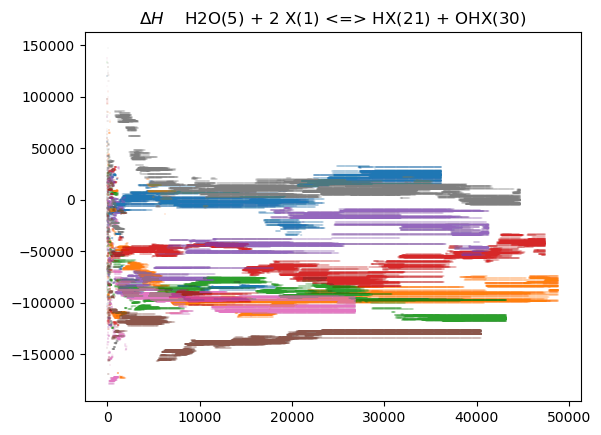

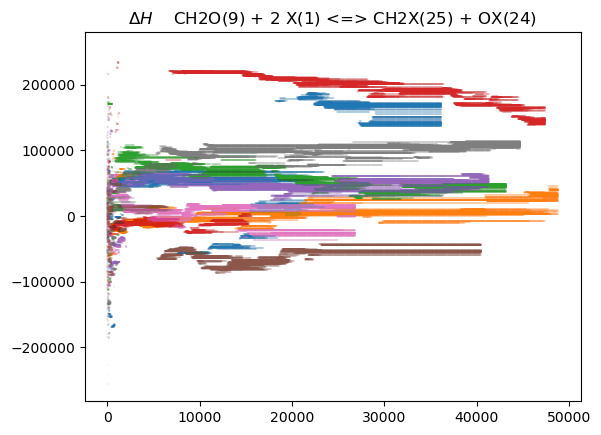

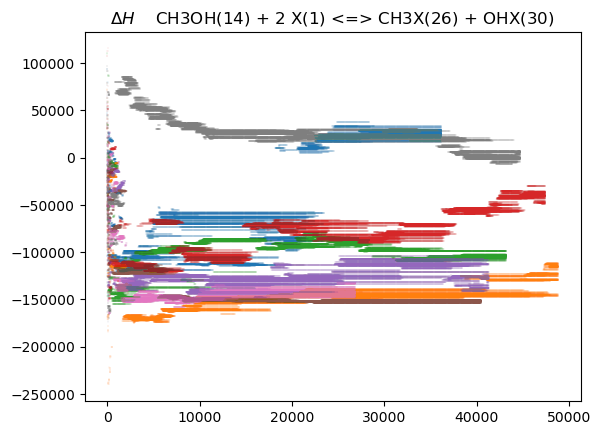

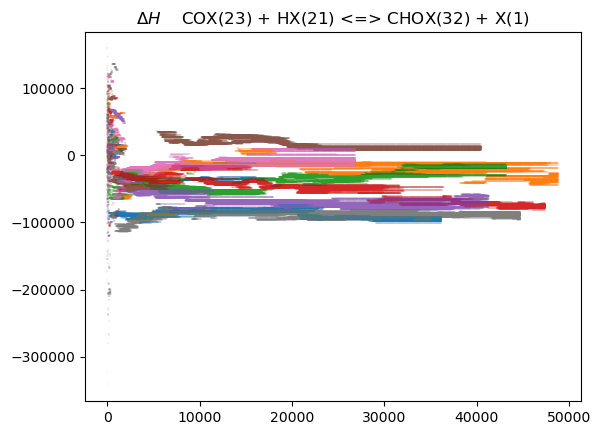

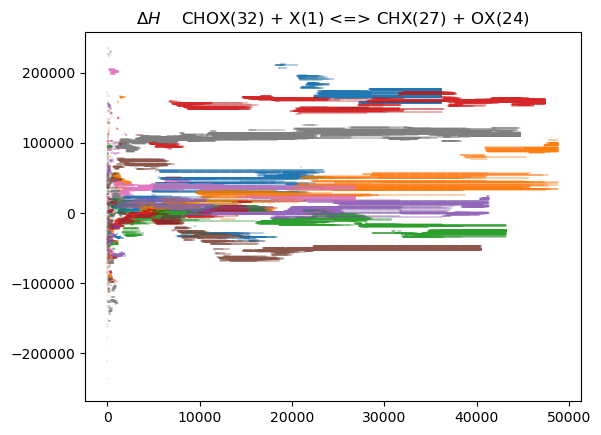

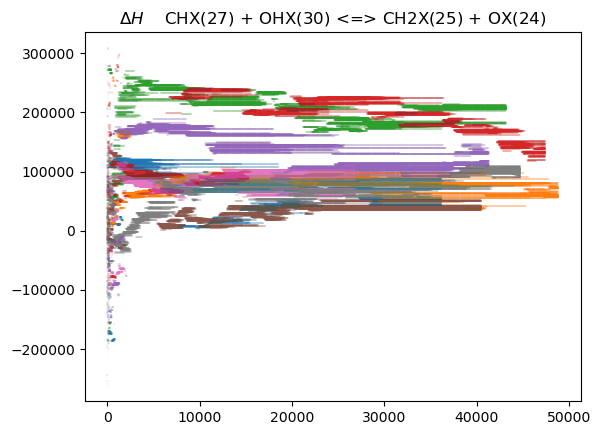

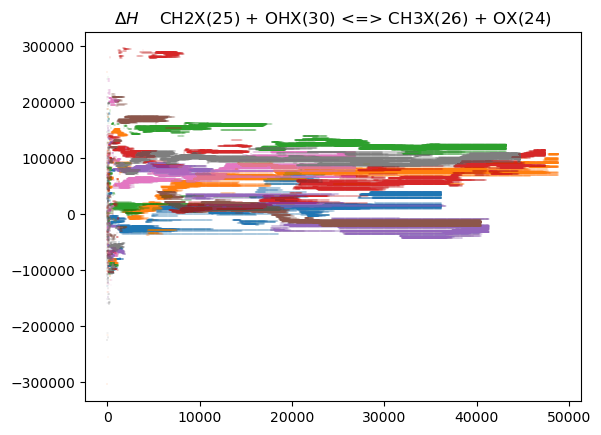

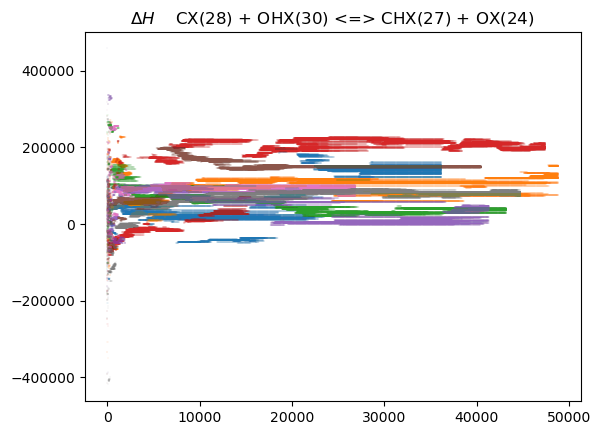

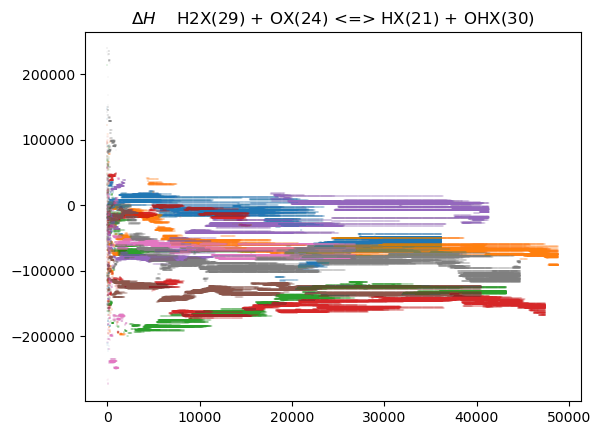

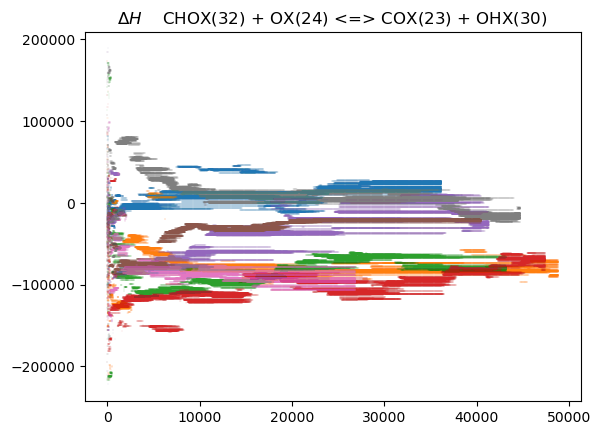

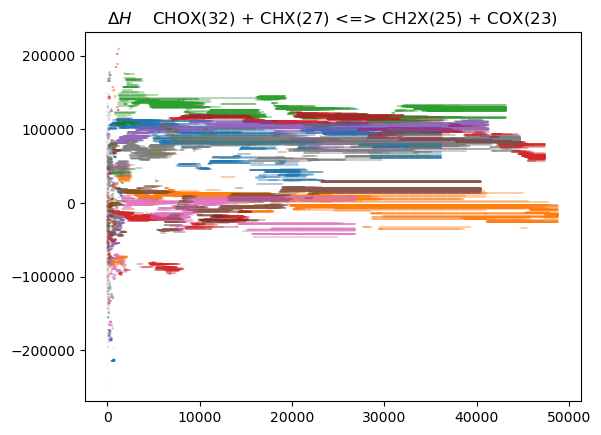

In [15]:
for reaction_index in reactions_of_interest[:25]:
    
    base_H_rxn = get_enthalpy_of_reaction(gas, surf, reaction_index)
    stoich_matrix = np.zeros(chain0.shape[2])
    for i in range(len(stoich_matrix)):
        surf_species_index = sim_info['prior_species_indices'][i]
        stoich_matrix[i] = surf.product_stoich_coeffs[surf_species_index, reaction_index] - surf.reactant_stoich_coeffs[surf_species_index, reaction_index]
    
    for j in range(len(chain_0s)):  # loop through 8 independent runners
        list_of_top_n_MAPs = all_run_MAPs[j]
        sample_indices = np.tile(np.arange(len(list_of_top_n_MAPs)) * chain0.shape[1], (n, 1)).T
        H_rxns = np.zeros_like(sample_indices) + 0.0
        for i in range(len(list_of_top_n_MAPs)):  # loop through number of samples
            H_rxns[i, :] = np.matmul(list_of_top_n_MAPs[i], stoich_matrix)
    
        plt.scatter(sample_indices, H_rxns, alpha=0.02, s=2, marker='_', label=f'run_{j}')
    
    # plt.legend()
    plt.title(r'$\Delta H$    ' + surf.reactions()[reaction_index].equation)
    plt.show()

# Plot cluster for one run

In [ ]:
list_of_top_n_logPs = []
list_of_top_n_MAPs = []

top_n_logPs = np.ones(n) * -np.inf
top_n_MAPs = np.zeros((n, N_params)) + np.nan

for i in range(logP0.shape[0]):
    new_logPs = logP0[i, :]
    new_MAPs = chain0[i, :, :]
    top_n_logPs, top_n_MAPs = add_new_data_point(top_n_logPs, top_n_MAPs, new_logPs, new_MAPs)

    new_logPs = logP1[i, :]
    new_MAPs = chain1[i, :, :]
    top_n_logPs, top_n_MAPs = add_new_data_point(top_n_logPs, top_n_MAPs, new_logPs, new_MAPs)
    
    list_of_top_n_logPs.append(top_n_logPs)
    list_of_top_n_MAPs.append(top_n_MAPs)

In [ ]:
for i in range(N_params):

    HXs = np.array(list_of_top_n_MAPs)[:, :, i]
    sample_indices = np.tile(np.arange(HXs.shape[0]) * chain0.shape[1], (n, 1)).T
    plt.scatter(sample_indices, HXs, alpha=0.02, s=2, marker='_')
    # plt.legend()
    plt.title(sim_info['parameter_names'][i])
    plt.show()

In [ ]:
logP0.shape

In [ ]:
2020 / (918 * 22)

In [ ]:
MAP.shape

In [ ]:
# For each parameter, plot the MAP vs chain length

MAPS = []
N_params = len(sim_info['parameter_names'])
for j in range(len(chain_0s)):
    
    chain0 = np.load(chain_0s[j])
    logP0 = np.load(logp_0s[j])
    chain1 = np.load(chain_0s[j])
    logP1 = np.load(logp_0s[j])

    MAP = np.zeros((max(chain0.shape[0], chain1.shape[0]), N_params))
    max_logP = -np.inf
    
    for i in range(max(chain0.shape[0], chain1.shape[0])):
        if i > 0:
            MAP[i, :] = MAP[i - 1, :]
        if i < chain0.shape[0]:
            i_best0 = np.argmax(logP0[i, :])
            if logP0[i, i_best0] > max_logP:
                max_logP = logP0[i, i_best0]
                MAP[i, :] = chain0[i, i_best0, :]
        if i < chain1.shape[0]:
            i_best1 = np.argmax(logP1[i, :])
            if logP1[i, i_best1] > max_logP:
                max_logP = logP1[i, i_best1]
                MAP[i, :] = chain1[i, i_best1, :]
    MAPS.append(MAP)

In [ ]:
for parameter in range(N_params):
    for i in range(len(MAPS)):
        plt.plot(np.arange(len(MAPS[i])) * 16.0, MAPS[i][:, parameter], label=f'run {i}')
    plt.legend()
    plt.title(sim_info['parameter_names'][parameter])
    plt.show()

In [ ]:
plt.plot(np.arange(min_length) * 16.0, MAP[:, 0])